<a href="https://colab.research.google.com/github/dpete0228/CSE455/blob/main/docs/course/data/cart/2016_01recommender_notebook_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Cart-based Recommendation System

This notebook is designed for your `cart` export CSV (extracted from your database). It builds a co-occurrence recommender:
1. **Co-occurrence-based** (people who added X also added Y) — great for "items in current cart → what else to recommend".

**Assumptions & notes**
- Input CSV should contain at least: `cart_session`, `cart_product_id`, `cart_quantity` (quantity optional). Each row is a cart line item.
- We'll treat interactions as implicit signals (presence = 1). Quantities are ignored by default.


In [125]:

# Standard imports
import math, os, json, pickle
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", 200)


In [126]:
# === 1) Load your CSV ===
# Replace the filename below with the path to your CSV exported from your database.
# Expected columns: cart_session, cart_product_id, cart_quantity (optional), cart_product_desc (optional)

CSV_PATH = "cart_export_11-15.csv"  # <<--- change this to your file path
EVAL_CSV = "answer_2016-01.csv"

In [127]:
print("Loading :", CSV_PATH)
df = pd.read_csv(CSV_PATH, dtype={"cart_session": str, "cart_product_id": object})
print("Rows:", len(df))
df.head()



Loading : cart_export_11-15.csv
Rows: 10348


,cart_session,cart_product_id,cart_quantity,cart_id,year,month
0,66c5afe9dcbabd09886d04bf4898a18c2c51ecd3,1,1,10014,2011,2
1,ec76f4bd1a933cc998dba373d239cec57b7c99ab,1,1,10016,2011,2
2,ec76f4bd1a933cc998dba373d239cec57b7c99ab,30,1,10017,2011,2
3,ec76f4bd1a933cc998dba373d239cec57b7c99ab,31,1,10018,2011,2
4,661af074bb69a5f5fac2b50edb9b862204e14cfd,4,1,10020,2011,2


Unique sessions: 2175
Unique products: 253
count    2175.000000
mean        4.757701
std         3.800408
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        29.000000
Name: line_items, dtype: float64


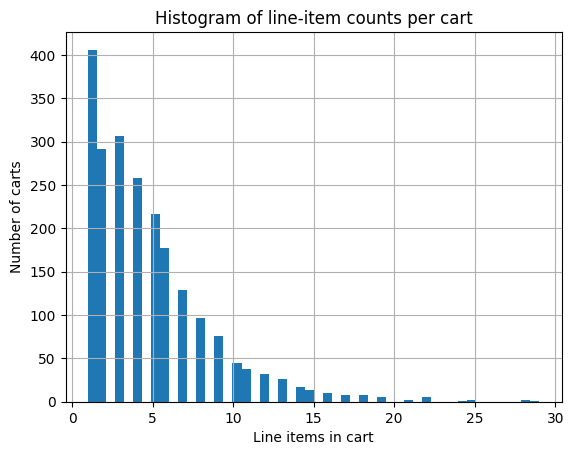

In [128]:

# === 2) Basic EDA ===
print("Unique sessions:", df['cart_session'].nunique())
print("Unique products:", df['cart_product_id'].nunique())

# Quick distribution of items per cart (line-item counts)
items_per_cart = df.groupby('cart_session').size().rename("line_items")
print(items_per_cart.describe())

# Histogram (line items)
items_per_cart.hist(bins=50)
plt.xlabel("Line items in cart")
plt.ylabel("Number of carts")
plt.title("Histogram of line-item counts per cart")
plt.show()


In [129]:
# === 3) Preprocessing ===
df = df.dropna(subset=['cart_session', 'cart_product_id']).copy()
df['cart_product_id'] = df['cart_product_id'].astype(str)

# Preserve product order of first appearance
product_ids = df['cart_product_id'].unique()
product_to_idx = {p: i for i, p in enumerate(product_ids)}
idx_to_product = {i: p for p, i in product_to_idx.items()}

# Preserve session order of first appearance (file order)
sessions = df['cart_session'].unique()
session_to_idx = {s: i for i, s in enumerate(sessions)}
idx_to_session = {i: s for s, i in session_to_idx.items()}

# IMPORTANT: sort=False preserves file order
transactions = (
    df
    .groupby('cart_session', sort=False)['cart_product_id']
    .apply(list)
    .to_dict()
)

# Convert products to indices
transactions = {
    session: [product_to_idx[p] for p in products]
    for session, products in transactions.items()
}

num_sessions = len(session_to_idx)
num_products = len(product_to_idx)

print("Sessions:", num_sessions, "Products:", num_products)


Sessions: 2175 Products: 253


In [130]:
# print a transaction as product ids
first_items = list(transactions.items())[1]
print(first_items)
# print first_items after converting them back to product_ids
first_items = [idx_to_product[i] for i in first_items[1]]
print("First transaction:", first_items)

('ec76f4bd1a933cc998dba373d239cec57b7c99ab', [0, 1, 2])
First transaction: ['1', '30', '31']


In [131]:

# === 4) Build sparse user-item matrix (binary presence) ===
rows = []
cols = []
data = []
for s, products in transactions.items():
    s_idx = session_to_idx[s]
    unique_products = set(products)
    for p_idx in unique_products:
        rows.append(s_idx)
        cols.append(p_idx)
        data.append(1)   # binary interaction

user_item = csr_matrix((data, (rows, cols)), shape=(num_sessions, num_products), dtype=np.float32)
print("User-item matrix shape:", user_item.shape, "nnz:", user_item.nnz)

User-item matrix shape: (2175, 253) nnz: 10283


In [132]:

# show user_item example
print("User-item matrix row 1:")
print(user_item.getrow(1).toarray())

User-item matrix row 1:
[[1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [133]:
#print the first 5 items from product_to_idx
print(list(product_to_idx.items())[:5])
# product_to_idx

[('1', 0), ('30', 1), ('31', 2), ('4', 3), ('36', 4)]


In [134]:

# === 5) Co-occurrence recommender ===
# We'll compute item co-occurrence counts and conditional probability P(j | i) ~ count(i,j) / count(i)

# Compute item counts (in how many sessions each item appears)
item_counts = np.array((user_item > 0).sum(axis=0)).ravel()  # shape (num_products,)
item_counts_dict = dict(enumerate(item_counts))

# Compute co-occurrence: item-item matrix = item_user.T dot item_user (but user_item is session x item)
cooccurrence = (user_item.T).dot(user_item)  # shape (num_products, num_products) as a sparse matrix
# cooccurrence[i,j] = number of sessions containing both i and j

def recommend_by_cooccurrence(items, top_n=10, exclude_existing=True):
    if isinstance(items, (str, int)):
        items = [items]
    scores = defaultdict(float)
    for i in items:
        i = int(i)
        # get cooccurrence row for i
        row = cooccurrence.getrow(i).toarray().ravel()
        # conditional probability P(j|i) = cooccurrence[i,j] / count(i)
        denom = item_counts_dict.get(i, 1)
        probs = row / float(denom) if denom > 0 else row
        for j, p in enumerate(probs):
            scores[j] += p
    # Exclude items already in cart
    if exclude_existing:
        for it in items:
            scores.pop(it, None)
    # Return top_n sorted by score
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return [(idx_to_product[i], float(score)) for i, score in ranked]



In [135]:
# Import the libraries we need
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [174]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
import xgboost as xgb

# 1. Build cart_history
sf = df.copy()
sf['cart_history'] = sf.groupby('cart_session', sort=False)[
    'cart_product_id'
].transform(lambda s: [s.iloc[:i].tolist() for i in range(len(s))])

# 2. Filter rows with prior history
sf_train = sf[sf['cart_history'].str.len() > 0].copy()

# Ensure IDs are strings to avoid type mismatches
sf_train['cart_history'] = sf_train['cart_history'].apply(
    lambda lst: [str(x) for x in lst]
)
sf_train['cart_product_id'] = sf_train['cart_product_id'].astype(str)

# 3. Extract the most recent item added
sf_train['last_item'] = sf_train['cart_history'].apply(lambda lst: lst[-1])

# 4. Feature 1: Multi-hot encode the entire cart history
# Initialize MultiLabelBinarizer with all known product IDs to prevent 'unknown class(es) will be ignored' warnings
mlb_history = MultiLabelBinarizer(classes=product_ids)
X_history = pd.DataFrame(
    mlb_history.fit_transform(sf_train['cart_history']),
    columns=[f"in_cart_{c}" for c in mlb_history.classes_],
    index=sf_train.index,
    dtype=np.int8,
)

# 5. Feature 2: One-hot encode the most recent item
# Initialize with all known product IDs as well
mlb_last = MultiLabelBinarizer(classes=product_ids)
X_last = pd.DataFrame(
    mlb_last.fit_transform(sf_train['last_item'].apply(lambda x: [x])),
    columns=[f"last_{c}" for c in mlb_history.classes_],
    index=sf_train.index,
    dtype=np.int8,
)

# 6. Combine both feature sets
X = pd.concat([X_history, X_last], axis=1)

# 7. Encode target
le = LabelEncoder()
# Fit LabelEncoder on ALL unique product IDs to ensure it knows about all possible target classes
le.fit(product_ids)
y = le.transform(sf_train['cart_product_id'])

# 8. Train XGBoost
clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
)

clf.fit(X, y)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 

In [165]:
import numpy as np
import pandas as pd

# === 1) XGBoost Predictor with Sequence Feature ===
def predict_cart_xgb(cart, clf, mlb_history, mlb_last, le, top_n=10):
    cart_str = [str(p) for p in cart]
    if not cart_str:
        return []

    last_item = cart_str[-1]

    # Create both feature blocks to match training schema
    x_hist = pd.DataFrame(
        mlb_history.transform([cart_str]),
        columns=[f"in_cart_{c}" for c in mlb_history.classes_],
        dtype=np.int8,
    )
    x_last = pd.DataFrame(
        mlb_last.transform([[last_item]]),
        columns=[f"last_{c}" for c in mlb_history.classes_],
        dtype=np.int8,
    )

    X_single = pd.concat([x_hist, x_last], axis=1)

    # Predict probabilities
    probs = clf.predict_proba(X_single)[0].copy()

    # Suppress items already in cart
    in_cart_set = set(cart_str)
    for idx, pid in enumerate(le.classes_):
        if pid in in_cart_set:
            probs[idx] = -1.0

    top_idx = np.argsort(-probs)[:top_n]
    return [(le.classes_[i], float(probs[i])) for i in top_idx if probs[i] >= 0]


# === 2) Popularity Fallback & Index Helpers ===
popular_idx = np.argsort(-item_counts)

def recommend_popular(top_n=10, exclude=[]):
    exclude_set = {str(e) for e in exclude}
    res = []
    for i in popular_idx:
        pid = str(idx_to_product[i])
        if pid in exclude_set:
            continue
        res.append((pid, int(item_counts[i])))
        if len(res) >= top_n:
            break
    return res

def product_ids_to_indices(product_ids_list):
    return [product_to_idx[str(p)] for p in product_ids_list if str(p) in product_to_idx]


# === 3) Master Recommendation Router ===
def recommend_for_current_cart(
    product_ids_in_cart,
    method="xgboost",
    top_n=10,
    clf=None,
    mlb_history=None,
    mlb_last=None,
    le=None,
):
    cart_str = [str(p) for p in product_ids_in_cart]

    # Universal fallback for completely empty carts
    if not cart_str:
        return recommend_popular(top_n=top_n, exclude=cart_str)

    if method == "xgboost":
        # Delegate directly to predict_cart_xgb
        return predict_cart_xgb(
            cart=cart_str,
            clf=clf,
            mlb_history=mlb_history,
            mlb_last=mlb_last,
            le=le,
            top_n=top_n,
        )

    if method == "cooccurrence":
        indices = product_ids_to_indices(cart_str)
        if not indices:
            return recommend_popular(top_n=top_n, exclude=cart_str)
        return recommend_by_cooccurrence(indices, top_n=top_n)

    if method == "popular":
        return recommend_popular(top_n=top_n, exclude=cart_str)

    raise ValueError(f"Unknown method: {method}")

In [143]:

# === 9) Example usage ===
# Replace these example product ids with ones from your data
example_cart = [list(product_to_idx.keys())[3]]  # single product example (raw id)
print("Example cart (raw ids):", example_cart)

print("\nCo-occurrence recommendations:")
print(recommend_for_current_cart(example_cart, method='cooccurrence', top_n=10))

# === Optional: save mappings and model artifacts ===
ARTIFACT_DIR = 'recommender_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
with open(os.path.join(ARTIFACT_DIR, 'mappings.pkl'), 'wb') as f:
    pickle.dump({'product_to_idx': product_to_idx, 'idx_to_product': idx_to_product,
                 'session_to_idx': session_to_idx, 'idx_to_session': idx_to_session}, f)
print('Saved artifacts to', ARTIFACT_DIR)


Example cart (raw ids): ['4']

Co-occurrence recommendations:
[('3', 0.21556885540485382), ('78', 0.1796407252550125), ('111', 0.1796407252550125), ('15', 0.17365269362926483), ('14', 0.17365269362926483), ('75', 0.16167664527893066), ('6', 0.1497005969285965), ('134', 0.1497005969285965), ('1', 0.13772454857826233), ('12', 0.13772454857826233)]
Saved artifacts to recommender_artifacts


In [144]:
example_cart = [1,30]
print("Example cart (raw ids):", example_cart)

print("\nCo-occurrence recommendations:")
print(recommend_for_current_cart(example_cart, method='cooccurrence', top_n=10))



Example cart (raw ids): [1, 30]

Co-occurrence recommendations:
[('111', 0.38122883439064026), ('12', 0.3369618058204651), ('78', 0.33575230836868286), ('0', 0.3243831694126129), ('4', 0.31132078170776367), ('6', 0.28543782234191895), ('72', 0.27987420558929443), ('62', 0.26632800698280334), ('75', 0.2660861313343048), ('14', 0.2602806091308594)]


In [166]:
import ast

# === 1) Load evaluation data ===


eval_df = pd.read_csv(
    EVAL_CSV,
    dtype={
        "sale_id": str,
        "prefix_length": int,
        "previous_products": str,
        "answer_product_ids": str
    }
)

print("Evaluation rows:", len(eval_df))

# Parse strings like '[260,4,323]' into lists
eval_df['previous_products']     = eval_df['previous_products'].apply(lambda x: [str(i) for i in ast.literal_eval(x)])
eval_df['answer_product_ids']    = eval_df['answer_product_ids'].apply(lambda x: [str(i) for i in ast.literal_eval(x)])
# === 2) Hit rate@k function ===
def hit_rate_at_k_any(df, method='cooccurrence', k=10):
    hits = 0
    total = len(df)

    for _, row in df.iterrows():
        cart = row['previous_products']
        answers = row['answer_product_ids']

        recs = recommend_for_current_cart(cart, method=method, top_n=k)
        rec_ids = [r[0] for r in recs]

        # any match counts as a hit
        if any(a in rec_ids for a in answers):
            hits += 1

    return hits / total if total > 0 else 0

# === 3) Evaluate each recommender ===
methods = ['cooccurrence']
for m in methods:
    hr = hit_rate_at_k_any(eval_df, method=m, k=10)
    print(f"Hit rate@10 for {m}: {hr:.4f}")



# hr5 = hit_rate_at_k_any(predictions, actuals, 5)
# hr10 = hit_rate_at_k_any(predictions, actuals, 10)

# print("HitRate@5:", hr5)
# print("HitRate@10:", hr10)

Evaluation rows: 281
Hit rate@10 for cooccurrence: 0.4021


In [175]:
import warnings

def hit_rate_at_k_any(
    df, method='xgboost', k=10, clf=None, mlb_history=None, mlb_last=None, le=None
):
    hits = 0
    total = len(df)

    for _, row in df.iterrows():
        cart = row['previous_products']
        answers = row['answer_product_ids']

        recs = recommend_for_current_cart(
            cart,
            method=method,
            top_n=k,
            clf=clf,
            mlb_history=mlb_history,
            mlb_last=mlb_last,
            le=le,
        )
        rec_ids = [r[0] for r in recs]

        if any(a in rec_ids for a in answers):
            hits += 1

    return hits / total if total > 0 else 0

# Suppress sklearn unrecognized class warnings during eval
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
    for m in ["popular", "cooccurrence", "xgboost"]:
        # Pass the initialized mlb_history, mlb_last, clf, and le objects
        hr10 = hit_rate_at_k_any(eval_df, method=m, k=10, clf=clf, mlb_history=mlb_history, mlb_last=mlb_last, le=le)
        print(f"Hit rate@10 for {m:12s}: {hr10:.4f}")


# === Compare All Methods ===
methods = ["popular", "cooccurrence", "xgboost"]

for m in methods:
    # Pass the initialized mlb_history, mlb_last, clf, and le objects
    hr10 = hit_rate_at_k_any(eval_df, method=m, k=10, clf=clf, mlb_history=mlb_history, mlb_last=mlb_last, le=le)
    print(f"Hit rate@10 for {m:12s}: {hr10:.4f}")

Hit rate@10 for popular     : 0.2562
Hit rate@10 for cooccurrence: 0.4021


NotFittedError: need to call fit or load_model beforehand

In [176]:
from collections import defaultdict
import numpy as np

WEIGHTS = {
    'xgboost': 0.5,
    'cooccurrence': 1.0,
    # 'popular': 0.5,
    # 'svd': 0.5  # Add back if you have an SVD score function
}

def _normalize_dict(score_dict):
    """Min-Max scales score values between 0.0 and 1.0."""
    if not score_dict:
        return {}
    vals = list(score_dict.values())
    min_v, max_v = min(vals), max(vals)
    if max_v == min_v:
        return {k: 1.0 for k in score_dict}
    return {k: (v - min_v) / (max_v - min_v) for k, v in score_dict.items()}


def recommend_hybrid(
    product_ids_in_cart,
    clf, mlb_history, mlb_last, le, # Changed from 'mlb' to 'mlb_history, mlb_last'
    top_n=10,
    exclude_existing=True,
    weights=WEIGHTS
):
    cart_str = [str(p) for p in product_ids_in_cart]
    indices = product_ids_to_indices(cart_str)

    # Fallback to pure popularity if the cart is empty or has only unknown items
    if not indices and not cart_str:
        return recommend_popular(top_n=top_n, exclude=cart_str)

    combined_scores = defaultdict(float)

    # ----------------------------------------------------
    # 1. XGBoost Scores
    # ----------------------------------------------------
    if weights.get('xgboost', 0) > 0 and clf is not None:
        try:
            # Construct features similar to predict_cart_xgb
            x_hist = pd.DataFrame(
                mlb_history.transform([cart_str]),
                columns=[f"in_cart_{c}" for c in mlb_history.classes_],
                dtype=np.int8,
            )
            last_item = cart_str[-1] if cart_str else '' # Handle empty cart case for last_item
            x_last = pd.DataFrame(
                mlb_last.transform([[last_item]]),
                columns=[f"last_{c}" for c in mlb_history.classes_],
                dtype=np.int8,
            )
            X_cart = pd.concat([x_hist, x_last], axis=1)

            probs = clf.predict_proba(X_cart)[0]
            # Map class labels to probabilities
            xgb_dict = {str(pid): float(prob) for pid, prob in zip(le.classes_, probs)}
            xgb_norm = _normalize_dict(xgb_dict)
            for pid, score in xgb_norm.items():
                combined_scores[pid] += weights['xgboost'] * score
        except Exception as e:
            print(f"XGBoost scoring failed: {e}") # Added error message
            pass  # Fall back gracefully if MLB encounters completely empty inputs

    # ----------------------------------------------------
    # 2. Co-occurrence Scores
    # ----------------------------------------------------
    if weights.get('cooccurrence', 0) > 0 and indices:
        co_scores = recommend_by_cooccurrence(
            indices,
            top_n=len(product_to_idx),
            exclude_existing=False
        )
        co_dict = {str(pid): float(s) for pid, s in co_scores}
        co_norm = _normalize_dict(co_dict)
        for pid, score in co_norm.items():
            combined_scores[pid] += weights['cooccurrence'] * score

    # ----------------------------------------------------
    # 3. Popularity Scores (Global Bias)
    # ----------------------------------------------------
    if weights.get('popular', 0) > 0:
        pop_dict = {str(idx_to_product[i]): float(item_counts[i]) for i in popular_idx}
        pop_norm = _normalize_dict(pop_dict)
        for pid, score in pop_norm.items():
            combined_scores[pid] += weights['popular'] * score

    # ----------------------------------------------------
    # Filter & Rank
    # ----------------------------------------------------
    if exclude_existing:
        for pid in cart_str:
            combined_scores.pop(pid, None)

    # Sort descending by weighted sum
    ranked = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return [(pid, float(score)) for pid, score in ranked]

In [177]:
example_cart = [240, 200, 277, 78]
target_answers = {'75', '4', '130'}

print("Example cart (raw ids):", example_cart)
print("\nHybrid recommendations:")

# Pass the model and encoders
recs = recommend_hybrid(example_cart, clf=clf, mlb_history=mlb_history, mlb_last=mlb_last, le=le, top_n=20)

for rank, (pid, score) in enumerate(recs, start=1):
    # Highlight if the recommended product is an actual target answer
    match_marker = " <--- HIT!" if pid in target_answers else ""
    print(f"{rank:2d}. Product ID: {pid:<6} | Score: {score:.4f}{match_marker}")

# Check hit status
rec_ids = {pid for pid, _ in recs}
hits = target_answers.intersection(rec_ids)

print(f"\nTarget Answers : {list(target_answers)}")
print(f"Hits found     : {list(hits) if hits else 'None'}")
print(f"Hit status     : {'SUCCESS' if hits else 'MISS'}")

Example cart (raw ids): [240, 200, 277, 78]

Hybrid recommendations:
XGBoost scoring failed: need to call fit or load_model beforehand
 1. Product ID: 75     | Score: 0.6257 <--- HIT!
 2. Product ID: 72     | Score: 0.4108
 3. Product ID: 227    | Score: 0.3805
 4. Product ID: 127    | Score: 0.3687
 5. Product ID: 111    | Score: 0.3581
 6. Product ID: 172    | Score: 0.3495
 7. Product ID: 62     | Score: 0.3430
 8. Product ID: 0      | Score: 0.3398
 9. Product ID: 1      | Score: 0.3381
10. Product ID: 12     | Score: 0.3259
11. Product ID: 14     | Score: 0.3158
12. Product ID: 206    | Score: 0.3074
13. Product ID: 144    | Score: 0.3059
14. Product ID: 15     | Score: 0.2834
15. Product ID: 134    | Score: 0.2737
16. Product ID: 80     | Score: 0.2718
17. Product ID: 123    | Score: 0.2641
18. Product ID: 4      | Score: 0.2608 <--- HIT!
19. Product ID: 130    | Score: 0.2533 <--- HIT!
20. Product ID: 173    | Score: 0.2515

Target Answers : ['75', '4', '130']
Hits found     : [